In [559]:
from sympy.core.random import sample
!pip install -r requirements.txt

## Razumevanje Podataka

### Učitavanje podataka

In [519]:
import pandas as pd
df = pd.read_csv("hf://datasets/sairamn/gcp-cloud-billing-cost/data.csv")

### Opisivanje podataka

Dataset koji smo izabrali sadrži sledeće atribute <br>
Resource ID - id resursa <br>
Service Name - Naziv GCP servisa <br>
Usage Quantity - Količina utrošenog resursa <br>
Usage Unit - Jedinica utrošenog resursa <br>
Region / Zone - Regija u kojoj se nalazi resurs <br>
CPU Utilization - Iskorišćenost procesora izražena u procentima <br>
Memory Utilization - Utoršenost memorije <br>
Network Inbound Data (Bytes) - Količina bajtova koju servis šalje preko mreže<br>
Network Outbound Data (Bytes) - Količina bajtova koju servis prima preko mreže<br>
Usage Start Date - Početak korišćenja <br>
Usage End Date - Kraj korišćenja <br>
Cost per Quanitity - Jedinična cena resursa <br>
Unrounded Cost - Nezaukružena cena <br>
Rounded Cost - Zaokružena cena <br>


Dataset ne poseduje NA vrednosti tako da nije potrebno vršiti čišćenje opservacija

In [520]:
df.shape

(124275, 15)

In [521]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Resource ID                    124275 non-null  str    
 1   Service Name                   124275 non-null  str    
 2   Usage Quantity                 124275 non-null  float64
 3   Usage Unit                     124275 non-null  str    
 4   Region / Zone                  124275 non-null  str    
 5   CPU Utilization (%)            124275 non-null  float64
 6   Memory Utilization (%)         124275 non-null  float64
 7   Network Inbound Data (Bytes)   124275 non-null  float64
 8   Network Outbound Data (Bytes)  124275 non-null  float64
 9   Usage Start Date               124275 non-null  str    
 10  Usage End Date                 124275 non-null  str    
 11  Cost per Quantity ($)          124275 non-null  float64
 12  Unrounded Cost ($)             124275 non

In [522]:
df.isna().sum().sum()

np.int64(0)

Cilj ovog modela je da uspesno predvidi troskove koriscenja cloud resursa za N nedelja. Konkretno nasa ideja je da uradimo Rolling sumu sa fiksnim klizecim prozorom, koja ce nam omoguciti da sabiramo troskove agregiranih redova po resurs ID-ju i po nedelji za fiksni interval od N nedelja.

Pre nego sto uradimo samu agregaciju, potrebno je da proverimo kvalitet podataka i da li je korektno raditi grupaciju po ova dva atributa

### Provera kvaliteta podataka i prirode promenljivi

Kako bismo uradili agregaciju potrebno je da proverimo da li je pravilno vrsiti grupaciju prema Resource ID-ju i Danu. Postoje i druge kategoricke promenljive po kojima je moguce vrsiti grupaciju, kao sto su Service Name, Usage Unit i Region / Zone

Smatramo da je nasa pocetna grupacija ispravna, jer na GCP-u jedan resurs id se moze odnositi samo na jednu vrstu cloud servisa. Takodje u generalno jedan cloud resurs sa jedinstvenim id-jem moze se nalaziti u jednom Regionu, isto vazi i za zonu dostupnosti, generalno je moguce imati jednu instancu samo u jednoj zoni, tako da cemo se u ovoj analizi predrzavati tog pravila. Usage Unit je kategoricka promenljiva koja je direktno povezana sa vrstom servisa i izbacicemo je iz razmatranja u daljem delu analize

In [523]:
print(df.groupby("Service Name")["Usage Unit"].unique())

Service Name
App Engine              [Hours]
Artifact Registry          [GB]
BigQuery             [Requests]
Cloud Armor          [Requests]
Cloud Build          [Requests]
Cloud CDN            [Requests]
Cloud Dataflow          [Hours]
Cloud Dataproc          [Hours]
Cloud Filestore            [GB]
Cloud Functions      [Requests]
Cloud Logging              [GB]
Cloud Memorystore          [GB]
Cloud Monitoring           [GB]
Cloud Pub/Sub        [Requests]
Cloud Run            [Requests]
Cloud SQL               [Hours]
Cloud Scheduler      [Requests]
Cloud Spanner           [Hours]
Cloud Storage              [GB]
Cloud Tasks          [Requests]
Compute Engine          [Hours]
Dialogflow           [Requests]
Secret Manager       [Requests]
Name: Usage Unit, dtype: object


Od numerickih promenljivi cemo na prvi pogled izbaciti kolone Rounded Cost i Total Cost koje zajedno sa promenljivom Unrounded Cost, predstavljaju izlaznu varijablu koju mi predvidjamo. Ove promenljive su izvedene jedna iz druge pa je kolinearnost veoma visoka. Ostavicemo samo kolonu Unrounded Cost.

In [524]:
df.drop(columns=['Usage Unit','Total Cost (INR)','Rounded Cost ($)', 'Resource ID'],inplace=True)

Nakon toga izdvojicemo iz promenljivih tipa datum sledeca vazna obelezja: <br>
Promenljivu week koja omogucava smisleno poredjenje datuma <br>
Promenljivu duration_of_hours koja oznacava trajanje koriscenja resursa <br>

In [525]:
df['Usage Start Date'] = pd.to_datetime(df['Usage Start Date'],errors='raise')
df['Usage End Date'] = pd.to_datetime(df['Usage End Date'],errors='raise')

df['duration_hours'] = (df['Usage End Date'] - df['Usage Start Date']).dt.total_seconds() / 3600
df.drop(columns=['Usage Start Date', 'Usage End Date'],inplace=True)

Nakon toga prikazujemo jos jednom tipove promenljivih

In [526]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Service Name                   124275 non-null  str    
 1   Usage Quantity                 124275 non-null  float64
 2   Region / Zone                  124275 non-null  str    
 3   CPU Utilization (%)            124275 non-null  float64
 4   Memory Utilization (%)         124275 non-null  float64
 5   Network Inbound Data (Bytes)   124275 non-null  float64
 6   Network Outbound Data (Bytes)  124275 non-null  float64
 7   Cost per Quantity ($)          124275 non-null  float64
 8   Unrounded Cost ($)             124275 non-null  float64
 9   duration_hours                 124275 non-null  float64
dtypes: float64(8), str(2)
memory usage: 9.5 MB


Takodje cemo izbaciti iz dataset-a, dve numericke promenljive koje logicki jako dobro predvidjaju izlazni trosak resursa a to su cost per quantity i Usage Quantity jer ce model davati jako veliki znacaj ovim atributima, sto nije nas fokus. Nas fokus je da se predvidja buduca potrosnja na osnovu istorijske tako da ce se ovde koristiti samo Usage Quantity kao istorijski podatak o iskoriscenosti

In [ ]:
#df.drop(columns='Cost per Quantity ($)',inplace=True)

Pre same agregacije izvrsicemo proveru negativnih vrednosti numerickih promenljiva, koje mogu nastati greskom upisa ili iz drugih tehnickih razloga kao sto su pretpostavljamo GCP krediti. U svakom slucaju izbacicemo one redove koje imaju negativne vrednosti

In [527]:
num_cols = ['Cost per Quantity ($)','Usage Quantity','CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)','duration_hours']

In [528]:
positive_instances = (df[num_cols] >= 0).all(axis=1)
df = df[positive_instances].reset_index(drop=True)

Nakon izbacivanja negativnih opservacija, radimo agregaciju po resursnom ID-ju (instanca cloud servisa) i nedelje. Konkretan razlog zasto ne radimo agregaciju po danima je zato sto dataset ne poseduje dovoljno unosa, da bi moglo kvalitetno predvidjanje da se izvrsi na dnevnom nivou

Agregacija funckionise na sledeci nacin, racunaju se totalne metrike za trosak, kolicinu koriscenja, trajanje i mrezni saobracaj, prosecne metrike za iskoriscenost procesora i memorije. Dok se Service i Region uzimaju od prvog reda u grupi sobzirom da smo pretpostavili da jedan moze biti samo jednog tipa i u jednoj regiji / zoni

Nakon kreiranja agregacije, vrsimo kreiranje kotrljajuce sume, sabirajuci metrike za svaku nedelju najvise num_of_weeks puta. Konkretno se za prozor koristi kalendarski datumi a ne datumi iz dataset-a. Tako da su uracunate rupe u dataset-u

Primer rolling sume za Resurs ID-ja 1

Za samu neuronsku mrezu vise nisu potrebni id resursa i nedelja koja se ne moze pretvoriti u numericki podatak. Sada postoji windows_weeks_count promenljiva koja ce se koristiti kao broj nedelja

## Provera multikolinearnosti

In [484]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr()
    plt.figure(figsize=(10, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Korelaciona matrica")
    plt.tight_layout()
    plt.show()

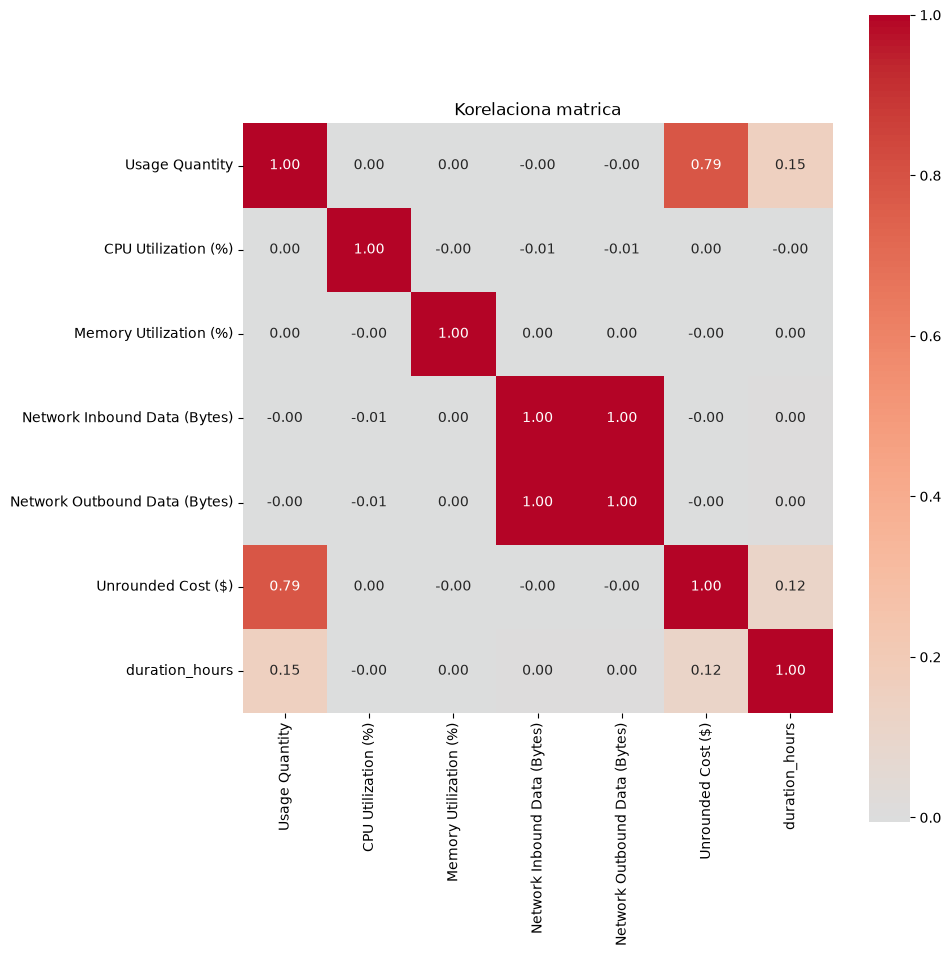

In [485]:
plot_correlation_heatmap(df,num_cols)

In [529]:
#df.drop(columns=['Usage Quantity','Network Inbound Data (Bytes)'], inplace=True)
#num_cols.remove('Usage Quantity')
df.drop(columns=['Network Inbound Data (Bytes)'], inplace=True)
num_cols.remove('Network Inbound Data (Bytes)')

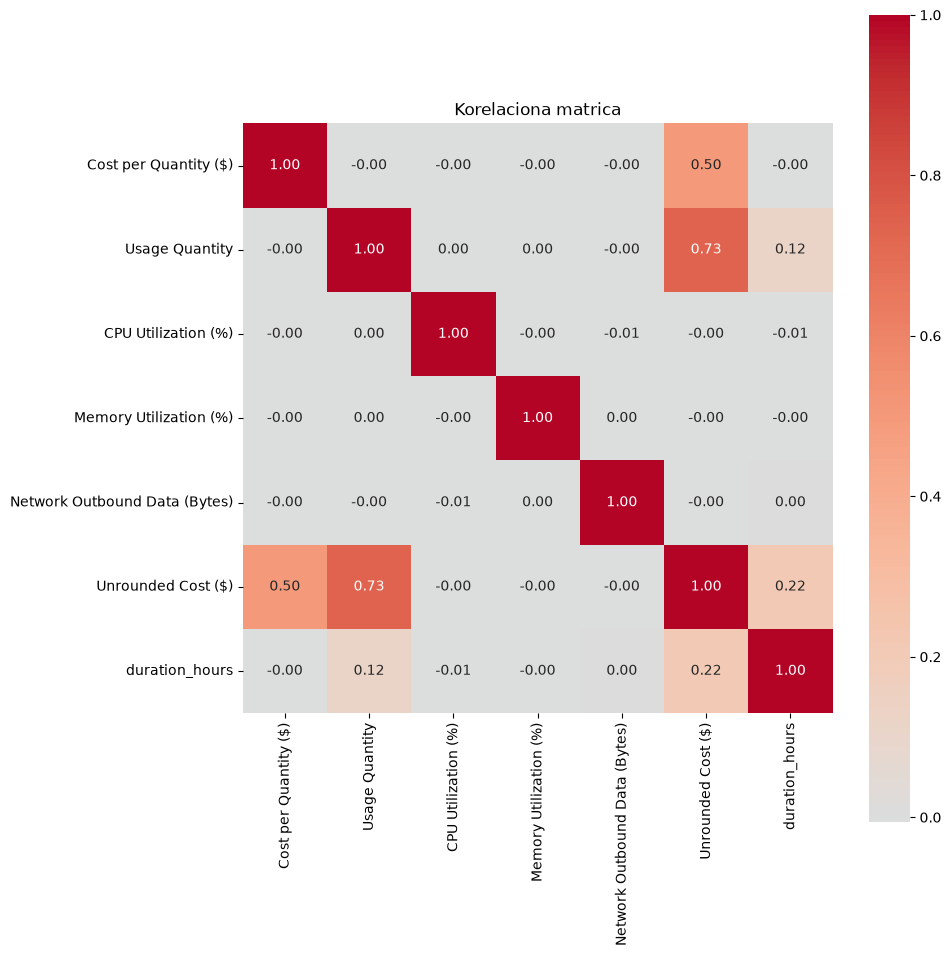

In [544]:
plot_correlation_heatmap(df,num_cols)

### Testiranje simetricnosti raspodela

Kako bismo omogucili skaliranje promenljivi i efikasni backpropagation, potrebno je testirati simetricnost raspodela promenljvi i transformisati promenljive sa asimetricnom raspodelom

In [530]:
import numpy as np
def plot_num_cols(df,columns,bins=40):
    n = len(columns)
    ncols = 3
    nrows = int(np.ceil(n/ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize= (6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        data = df[col].dropna()
        label = col
        axes[i].hist(data, bins=bins,color='blue',edgecolor='black', alpha=0.8)
        axes[i].set_title(label)
        axes[i].set_xlabel(label)
        axes[i].set_ylabel("broj opservacija")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

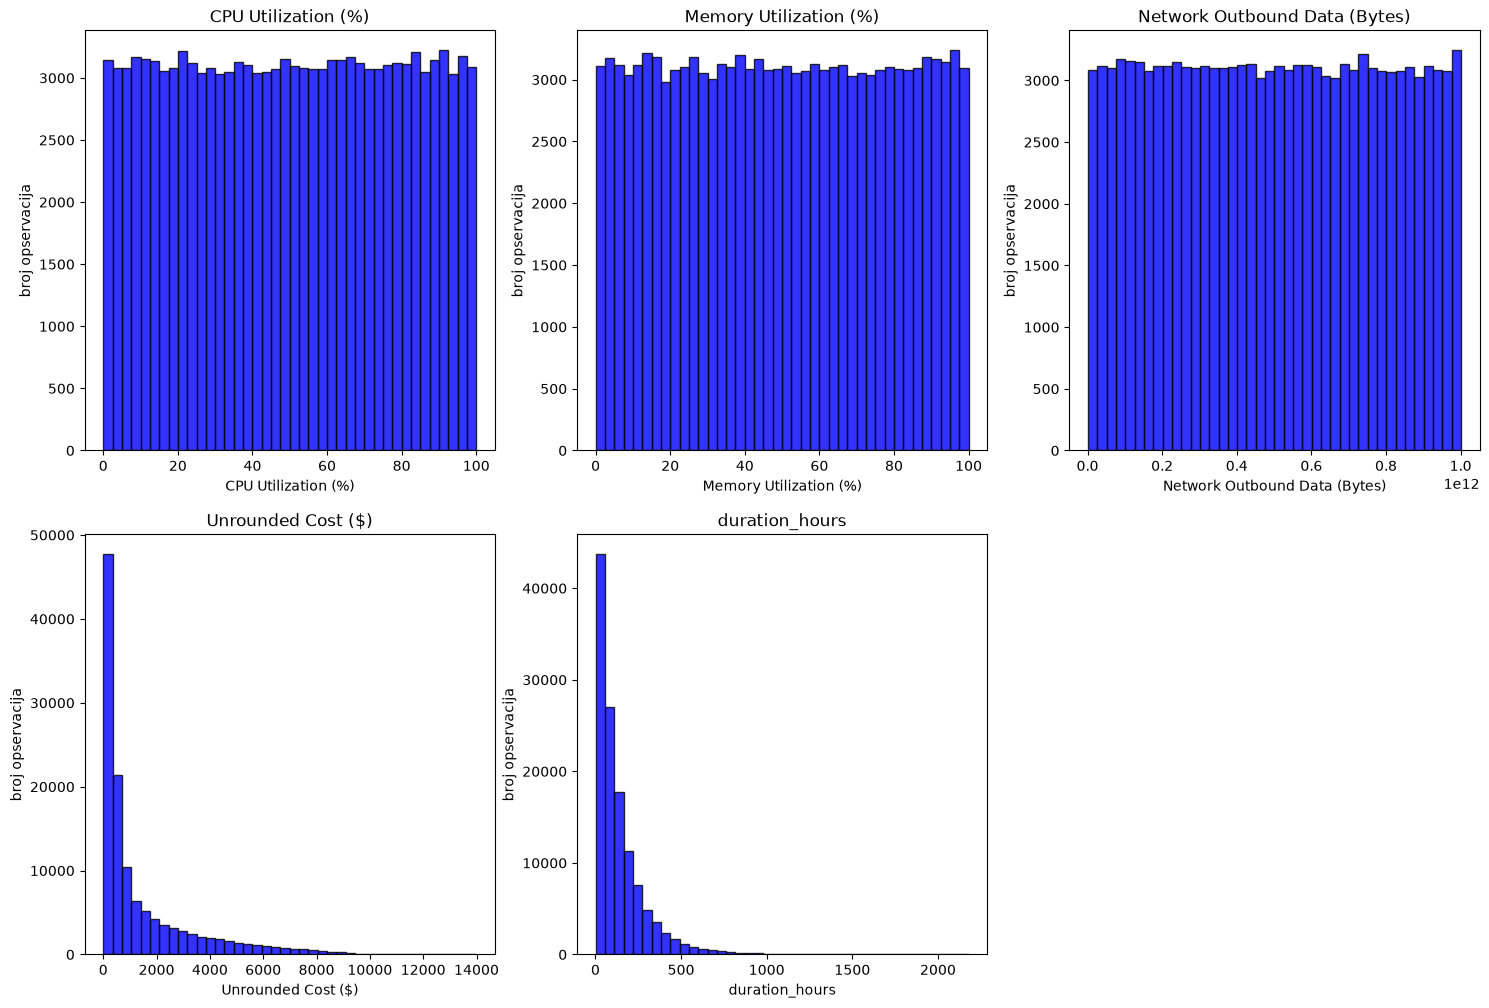

In [488]:
plot_num_cols(df,num_cols)

Takodje cemo uraditi test asimetricnosti kako bismo imali dodatnu potvrdu o asimetricnosti

Na osnovu datih grafikona raspodela može se zaključiti da sumarne metrike imaju raspodelu asimetricnu udesno. Primenicemo logaritamsku tranformaciju kako bismo korigovali ove raspodele

In [531]:
from scipy.stats import skew
for col in num_cols:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Cost per Quantity ($): skew = 0.001
Usage Quantity: skew = 1.022
CPU Utilization (%): skew = -0.004
Memory Utilization (%): skew = 0.002
Network Outbound Data (Bytes): skew = 0.005
Unrounded Cost ($): skew = 1.875
duration_hours: skew = 2.708


In [532]:
df['Unrounded Cost ($)'] = np.log1p(df['Unrounded Cost ($)'])
df['duration_hours'] = np.log1p(df['duration_hours'])

### Graficki prikaz raspodela transformisanih kolona

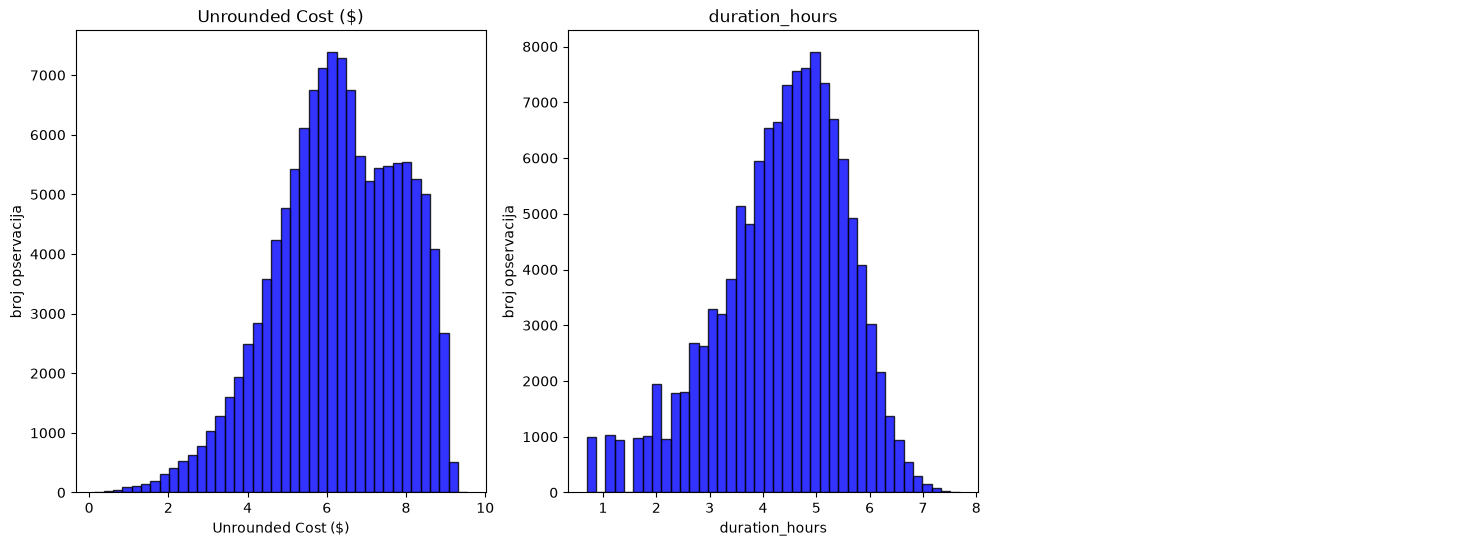

In [491]:
plot_num_cols(df,['Unrounded Cost ($)','duration_hours'])

Sada sumarne skale teze simetricnim raspodelama

In [492]:
for col in ['Unrounded Cost ($)','duration_hours']:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Unrounded Cost ($): skew = -0.394
duration_hours: skew = -0.596


Poslednje sto moramo da uradimo je konvertujemo numericke promenljive service i region u numericke, to cemo postici one-hot encoding-om

In [533]:
def one_hot_encode_col(dataframe, column):
    ohe = pd.get_dummies(dataframe[column], dtype=int)
    df_res = pd.concat([dataframe.drop(columns=column),ohe], axis=1)
    return df_res

In [534]:
df = one_hot_encode_col(df,'Service Name')
df = one_hot_encode_col(df,'Region / Zone')

In [495]:
df.sample(n = 10, random_state = 17)

,CPU Utilization (%),Memory Utilization (%),Network Outbound Data (Bytes),Unrounded Cost ($),duration_hours,App Engine,Artifact Registry,BigQuery,Cloud Armor,Cloud Build,...,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager,asia-east1,asia-south1,europe-west1,us-central1,us-east1,us-west1
89924,9.17,89.07,1.306690e+11,7.864553,5.541264,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
57738,9.43,11.88,6.157440e+11,5.042909,5.342334,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
62271,40.11,28.23,7.254920e+11,6.861472,5.181784,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
98228,18.21,61.31,5.935249e+10,6.683426,4.543295,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
33495,77.47,62.08,7.896220e+11,2.959359,1.098612,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
850,5.18,37.36,9.005960e+11,5.582257,4.624973,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
25974,60.76,87.86,5.518410e+11,5.694924,6.161207,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
109838,88.95,74.52,6.426880e+11,7.712348,5.398163,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
64138,22.84,14.71,5.757210e+11,6.223537,5.332719,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
76491,69.66,92.95,2.719520e+11,5.721501,4.276666,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [496]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CPU Utilization (%)            124275 non-null  float64
 1   Memory Utilization (%)         124275 non-null  float64
 2   Network Outbound Data (Bytes)  124275 non-null  float64
 3   Unrounded Cost ($)             124275 non-null  float64
 4   duration_hours                 124275 non-null  float64
 5   App Engine                     124275 non-null  int64  
 6   Artifact Registry              124275 non-null  int64  
 7   BigQuery                       124275 non-null  int64  
 8   Cloud Armor                    124275 non-null  int64  
 9   Cloud Build                    124275 non-null  int64  
 10  Cloud CDN                      124275 non-null  int64  
 11  Cloud Dataflow                 124275 non-null  int64  
 12  Cloud Dataproc                 124275 non

## Skaliranje podataka i treniranje model2a

In [535]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def evaluate_regression_model(model, data_loader):

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            outputs = model(batch_X)
            all_preds.append(outputs.view(-1).numpy())
            all_targets.append(batch_y.view(-1).numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Reverse the log transformation (np.log1p) to return to original units
    all_preds_actual = np.expm1(all_preds)
    all_targets_actual = np.expm1(all_targets)

    # Calculate metrics using the actual values
    mse = mean_squared_error(all_targets_actual, all_preds_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets_actual, all_preds_actual)
    r2 = r2_score(all_targets_actual, all_preds_actual)
    mape = mean_absolute_percentage_error(all_targets_actual, all_preds_actual)

    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

    print(f"Model Evaluation Metrics (Original Units):")
    for name, value in metrics.items():
        # Display MAPE as a percentage for better readability
        display_value = value * 100 if name == "MAPE" else value
        unit = "%" if name == "MAPE" else ""
        print(f"  {name:4}: {display_value:.4f}{unit}")

    return metrics

In [537]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Prepare Data
target_col = 'Unrounded Cost ($)'
X = df.drop(columns=[target_col])
y = df[target_col].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Scaling
cols_to_scale = ['Cost per Quantity ($)','Usage Quantity','CPU Utilization (%)', 'Memory Utilization (%)', 'Network Outbound Data (Bytes)', 'duration_hours']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), cols_to_scale)],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train).astype(np.float32)
X_val = preprocessor.transform(X_val).astype(np.float32)
X_test = preprocessor.transform(X_test).astype(np.float32)

# Convert to Tensors
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val.astype(np.float32)))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

## Počinjemo sa jedostavnim modelom koji ima 2 skrivena sloja, koristi sigmoidnu aktivacionu funkciju u oba sloja, kao i stochastic gradient descent sa fixnim learning rate-om.

In [ ]:
class CostPredictor1(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Sigmoid(),
            nn.Linear(64, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = CostPredictor1(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
import numpy as np

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 8  # Stop after 8 epochs of no improvement
trigger_count = 0
best_model_state = None

for epoch in range(50):
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses.append(epoch_train_loss / len(train_loader))
    val_losses.append(current_avg_loss)

    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    current_avg_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Val Loss: {current_avg_loss:.4f}")

    # Early Stopping Logic
    if current_avg_loss < best_val_loss:
        best_val_loss = current_avg_loss
        trigger_count = 0
        # Save the best weights
        best_model_state = model.state_dict()
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            # Restore best weights
            model.load_state_dict(best_model_state)
            break

Epoch 1, Val Loss: 0.4184
Epoch 2, Val Loss: 0.4009
Epoch 3, Val Loss: 0.3883
Epoch 4, Val Loss: 0.3692
Epoch 5, Val Loss: 0.3143
Epoch 6, Val Loss: 0.2659
Epoch 7, Val Loss: 0.1989
Epoch 8, Val Loss: 0.1565
Epoch 9, Val Loss: 0.1304
Epoch 10, Val Loss: 0.1145
Epoch 11, Val Loss: 0.1010
Epoch 12, Val Loss: 0.0949
Epoch 13, Val Loss: 0.0832
Epoch 14, Val Loss: 0.0756
Epoch 15, Val Loss: 0.0718
Epoch 16, Val Loss: 0.0674
Epoch 17, Val Loss: 0.0618
Epoch 18, Val Loss: 0.0562
Epoch 19, Val Loss: 0.0506
Epoch 20, Val Loss: 0.0470
Epoch 21, Val Loss: 0.0466
Epoch 22, Val Loss: 0.0414
Epoch 23, Val Loss: 0.0384
Epoch 24, Val Loss: 0.0370
Epoch 25, Val Loss: 0.0339
Epoch 26, Val Loss: 0.0321
Epoch 27, Val Loss: 0.0308
Epoch 28, Val Loss: 0.0286
Epoch 29, Val Loss: 0.0271
Epoch 30, Val Loss: 0.0257
Epoch 31, Val Loss: 0.0246
Epoch 32, Val Loss: 0.0237
Epoch 33, Val Loss: 0.0220
Epoch 34, Val Loss: 0.0211
Epoch 35, Val Loss: 0.0205
Epoch 36, Val Loss: 0.0196
Epoch 37, Val Loss: 0.0189
Epoch 38, 

## Evaluiramo model i na testnom i na validacionom setu (ako validacioni mnogo bolji od testnog, znači da je u pitanju overfitting)

In [ ]:
print("Evaluating on Test Set:")
test_results = evaluate_regression_model(model, test_loader)

print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model, val_loader)

Evaluating on Test Set:
Model Evaluation Metrics (Original Units):
  MSE : 16219.7734
  RMSE: 127.3569
  MAE : 56.2775
  R2  : 0.9954
  MAPE: 7.1255%

Evaluating on Validation Set:
Model Evaluation Metrics (Original Units):
  MSE : 15838.5547
  RMSE: 125.8513
  MAE : 56.1339
  R2  : 0.9955
  MAPE: 7.1375%


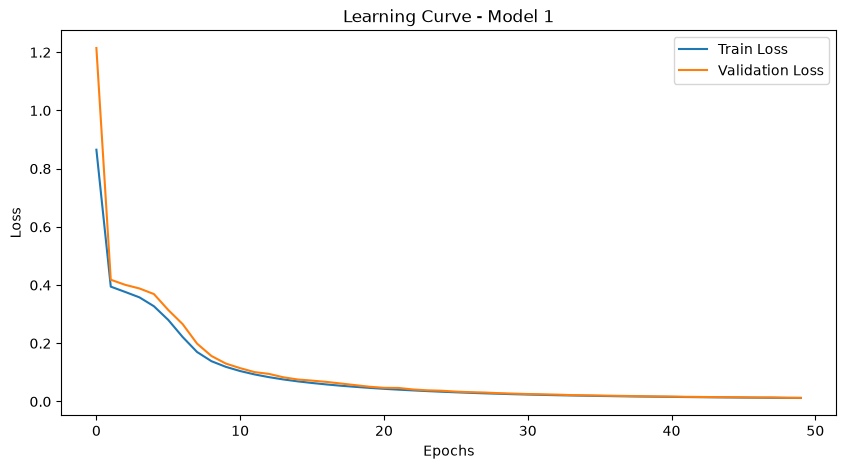

In [541]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve - Model 1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Hajde sada da probamo da umesto MSE korsitimo Huberovu loss funckiju, koja je takođe česta kada su u pitanju regrasioni zadaci.

In [ ]:
class CostPredictor2(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Sigmoid(),
            nn.Linear(64, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model2 = CostPredictor2(X_train.shape[1])
criterion = nn.HuberLoss(delta=1)
optimizer = optim.SGD(model2.parameters(), lr=0.01)

In [ ]:
best_val_loss = float('inf')
patience = 8 
trigger_count = 0
best_model2_state = None
train_losses2 = []
val_losses2 = []

for epoch in range(50):
    model2.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model2(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses2.append(epoch_train_loss / len(train_loader))
    val_losses2.append(current_avg_loss)

    
    
    model2.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model2(batch_X)
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    current_avg_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Val Loss: {current_avg_loss:.4f}")

    # Early Stopping Logic
    if current_avg_loss < best_val_loss:
        best_val_loss = current_avg_loss
        trigger_count = 0
        # Save the best weights
        best_model2_state = model2.state_dict()
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            # Restore best weights
            model2.load_state_dict(best_model2_state)
            break

Epoch 1, Val Loss: 0.2757
Epoch 2, Val Loss: 0.1975
Epoch 3, Val Loss: 0.1879
Epoch 4, Val Loss: 0.1792
Epoch 5, Val Loss: 0.1752
Epoch 6, Val Loss: 0.1719
Epoch 7, Val Loss: 0.1690
Epoch 8, Val Loss: 0.1661
Epoch 9, Val Loss: 0.1625
Epoch 10, Val Loss: 0.1585
Epoch 11, Val Loss: 0.1526
Epoch 12, Val Loss: 0.1462
Epoch 13, Val Loss: 0.1386
Epoch 14, Val Loss: 0.1297
Epoch 15, Val Loss: 0.1204
Epoch 16, Val Loss: 0.1111
Epoch 17, Val Loss: 0.1012
Epoch 18, Val Loss: 0.0916
Epoch 19, Val Loss: 0.0820
Epoch 20, Val Loss: 0.0743
Epoch 21, Val Loss: 0.0674
Epoch 22, Val Loss: 0.0616
Epoch 23, Val Loss: 0.0573
Epoch 24, Val Loss: 0.0537
Epoch 25, Val Loss: 0.0503
Epoch 26, Val Loss: 0.0473
Epoch 27, Val Loss: 0.0447
Epoch 28, Val Loss: 0.0423
Epoch 29, Val Loss: 0.0401
Epoch 30, Val Loss: 0.0379
Epoch 31, Val Loss: 0.0363
Epoch 32, Val Loss: 0.0347
Epoch 33, Val Loss: 0.0328
Epoch 34, Val Loss: 0.0317
Epoch 35, Val Loss: 0.0302
Epoch 36, Val Loss: 0.0294
Epoch 37, Val Loss: 0.0274
Epoch 38, 

In [545]:
print("Evaluating on Test Set:")
test_results = evaluate_regression_model(model2, test_loader)

print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model2, val_loader)

Evaluating on Test Set:
Model Evaluation Metrics (Original Units):
  MSE : 18443.8145
  RMSE: 135.8080
  MAE : 80.2912
  R2  : 0.9947
  MAPE: 13.0376%

Evaluating on Validation Set:
Model Evaluation Metrics (Original Units):
  MSE : 18801.6641
  RMSE: 137.1192
  MAE : 81.3542
  R2  : 0.9947
  MAPE: 13.2918%


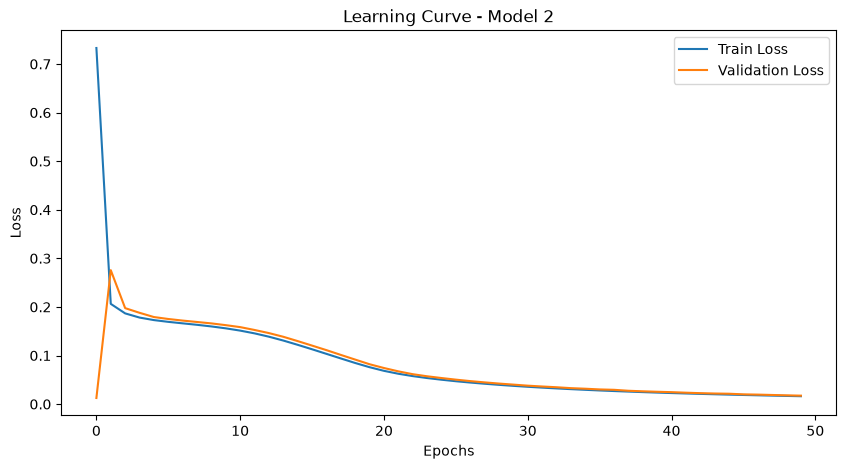

In [546]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses2, label='Train Loss')
plt.plot(val_losses2, label='Validation Loss')
plt.title('Learning Curve - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Na grafiku se vidi da sporije dolazimo do losijeg rezultata, pa cemo zadrzati MSE. Sada cemo probati da zamenimo sigmoidne aktivacione funkcije ReLU koja je gotovo uvek bolja opcija, jer izmedju ostalog resava vanishing gradient problem.

In [ ]:
class CostPredictor3(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor3, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model3 = CostPredictor3(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model3.parameters(), lr=0.01)



In [548]:
best_val_loss = float('inf')
patience = 8
trigger_count = 0
best_model3_state = None
train_losses3 = []
val_losses3 = []

for epoch in range(50):
    model3.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model3(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses3.append(epoch_train_loss / len(train_loader))
    
    model3.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model3(batch_X)
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    current_avg_loss = val_loss / len(val_loader)
    val_losses3.append(current_avg_loss)
    print(f"Epoch {epoch+1}, Val Loss: {current_avg_loss:.4f}")

    if current_avg_loss < best_val_loss:
        best_val_loss = current_avg_loss
        trigger_count = 0
        best_model3_state = model3.state_dict()
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model3.load_state_dict(best_model3_state)
            break

Epoch 1, Val Loss: 0.0748
Epoch 2, Val Loss: 0.0301
Epoch 3, Val Loss: 0.0499
Epoch 4, Val Loss: 0.0137
Epoch 5, Val Loss: 0.0108
Epoch 6, Val Loss: 0.0076
Epoch 7, Val Loss: 0.0071
Epoch 8, Val Loss: 0.0059
Epoch 9, Val Loss: 0.0054
Epoch 10, Val Loss: 0.0073
Epoch 11, Val Loss: 0.0046
Epoch 12, Val Loss: 0.0050
Epoch 13, Val Loss: 0.0038
Epoch 14, Val Loss: 0.0039
Epoch 15, Val Loss: 0.0040
Epoch 16, Val Loss: 0.0042
Epoch 17, Val Loss: 0.0053
Epoch 18, Val Loss: 0.0035
Epoch 19, Val Loss: 0.0031
Epoch 20, Val Loss: 0.0035
Epoch 21, Val Loss: 0.0030
Epoch 22, Val Loss: 0.0028
Epoch 23, Val Loss: 0.0027
Epoch 24, Val Loss: 0.0038
Epoch 25, Val Loss: 0.0025
Epoch 26, Val Loss: 0.0024
Epoch 27, Val Loss: 0.0030
Epoch 28, Val Loss: 0.0029
Epoch 29, Val Loss: 0.0024
Epoch 30, Val Loss: 0.0030
Epoch 31, Val Loss: 0.0028
Epoch 32, Val Loss: 0.0038
Epoch 33, Val Loss: 0.0029
Epoch 34, Val Loss: 0.0022
Epoch 35, Val Loss: 0.0028
Epoch 36, Val Loss: 0.0023
Epoch 37, Val Loss: 0.0025
Epoch 38, 

In [549]:
print("Evaluating on Test Set:")
test_results = evaluate_regression_model(model3, test_loader)

print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model3, val_loader)

Evaluating on Test Set:
Model Evaluation Metrics (Original Units):
  MSE : 5905.1162
  RMSE: 76.8448
  MAE : 34.1119
  R2  : 0.9983
  MAPE: 3.5266%

Evaluating on Validation Set:
Model Evaluation Metrics (Original Units):
  MSE : 5420.4453
  RMSE: 73.6237
  MAE : 34.0222
  R2  : 0.9985
  MAPE: 3.4998%


## ReLU daje odličan rezultat. Probajmo još jednog popularnog kandidata, tanh funkciju. Ona ne eleminiše vanishing gradient, ali zato moze dovesti do ubrzanog ucenja.

In [550]:
class CostPredictor4(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor4, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model4 = CostPredictor4(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model4.parameters(), lr=0.01)

In [551]:
best_val_loss = float('inf')
patience = 8
trigger_count = 0
best_model4_state = None
train_losses4 = []
val_losses4 = []

for epoch in range(50):
    model4.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model4(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses4.append(epoch_train_loss / len(train_loader))
    
    model4.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model4(batch_X)
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    current_avg_loss = val_loss / len(val_loader)
    val_losses4.append(current_avg_loss)
    print(f"Epoch {epoch+1}, Val Loss: {current_avg_loss:.4f}")

    if current_avg_loss < best_val_loss:
        best_val_loss = current_avg_loss
        trigger_count = 0
        best_model4_state = model4.state_dict()
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model4.load_state_dict(best_model4_state)
            break

Epoch 1, Val Loss: 0.1003
Epoch 2, Val Loss: 0.0532
Epoch 3, Val Loss: 0.0304
Epoch 4, Val Loss: 0.0240
Epoch 5, Val Loss: 0.0151
Epoch 6, Val Loss: 0.0121
Epoch 7, Val Loss: 0.0107
Epoch 8, Val Loss: 0.0096
Epoch 9, Val Loss: 0.0084
Epoch 10, Val Loss: 0.0078
Epoch 11, Val Loss: 0.0066
Epoch 12, Val Loss: 0.0066
Epoch 13, Val Loss: 0.0055
Epoch 14, Val Loss: 0.0054
Epoch 15, Val Loss: 0.0048
Epoch 16, Val Loss: 0.0049
Epoch 17, Val Loss: 0.0044
Epoch 18, Val Loss: 0.0042
Epoch 19, Val Loss: 0.0042
Epoch 20, Val Loss: 0.0038
Epoch 21, Val Loss: 0.0046
Epoch 22, Val Loss: 0.0035
Epoch 23, Val Loss: 0.0031
Epoch 24, Val Loss: 0.0029
Epoch 25, Val Loss: 0.0031
Epoch 26, Val Loss: 0.0028
Epoch 27, Val Loss: 0.0026
Epoch 28, Val Loss: 0.0024
Epoch 29, Val Loss: 0.0028
Epoch 30, Val Loss: 0.0023
Epoch 31, Val Loss: 0.0022
Epoch 32, Val Loss: 0.0021
Epoch 33, Val Loss: 0.0020
Epoch 34, Val Loss: 0.0021
Epoch 35, Val Loss: 0.0020
Epoch 36, Val Loss: 0.0019
Epoch 37, Val Loss: 0.0021
Epoch 38, 

In [552]:
print("Evaluating on Test Set:")
test_results = evaluate_regression_model(model4, test_loader)

print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model4, val_loader)

Evaluating on Test Set:
Model Evaluation Metrics (Original Units):
  MSE : 1026.5372
  RMSE: 32.0396
  MAE : 16.1044
  R2  : 0.9997
  MAPE: 2.0775%

Evaluating on Validation Set:
Model Evaluation Metrics (Original Units):
  MSE : 1035.3279
  RMSE: 32.1765
  MAE : 16.0964
  R2  : 0.9997
  MAPE: 2.1219%


## Tanh je pobednik. Posto vidimo da loss funkcija cesto preskace minimum i povecava se, mozda je problem u learning rate-u. Koristicemo Adam (algoritam koji prilagodjava learning rate). 

In [553]:
class CostPredictor5(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor5, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model5 = CostPredictor5(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model5.parameters(), lr=0.001)

In [554]:
best_val_loss = float('inf')
patience = 8
trigger_count = 0
best_model5_state = None
train_losses5 = []
val_losses5 = []

for epoch in range(50):
    model5.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model5(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses5.append(epoch_train_loss / len(train_loader))
    
    model5.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model5(batch_X)
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    current_avg_loss = val_loss / len(val_loader)
    val_losses5.append(current_avg_loss)
    print(f"Epoch {epoch+1}, Val Loss: {current_avg_loss:.4f}")

    if current_avg_loss < best_val_loss:
        best_val_loss = current_avg_loss
        trigger_count = 0
        best_model5_state = model5.state_dict()
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model5.load_state_dict(best_model5_state)
            break

Epoch 1, Val Loss: 0.0559
Epoch 2, Val Loss: 0.0133
Epoch 3, Val Loss: 0.0075
Epoch 4, Val Loss: 0.0044
Epoch 5, Val Loss: 0.0049
Epoch 6, Val Loss: 0.0045
Epoch 7, Val Loss: 0.0028
Epoch 8, Val Loss: 0.0027
Epoch 9, Val Loss: 0.0051
Epoch 10, Val Loss: 0.0042
Epoch 11, Val Loss: 0.0024
Epoch 12, Val Loss: 0.0034
Epoch 13, Val Loss: 0.0026
Epoch 14, Val Loss: 0.0036
Epoch 15, Val Loss: 0.0023
Epoch 16, Val Loss: 0.0015
Epoch 17, Val Loss: 0.0035
Epoch 18, Val Loss: 0.0015
Epoch 19, Val Loss: 0.0018
Epoch 20, Val Loss: 0.0022
Epoch 21, Val Loss: 0.0032
Epoch 22, Val Loss: 0.0012
Epoch 23, Val Loss: 0.0015
Epoch 24, Val Loss: 0.0022
Epoch 25, Val Loss: 0.0008
Epoch 26, Val Loss: 0.0013
Epoch 27, Val Loss: 0.0029
Epoch 28, Val Loss: 0.0036
Epoch 29, Val Loss: 0.0024
Epoch 30, Val Loss: 0.0013
Epoch 31, Val Loss: 0.0018
Epoch 32, Val Loss: 0.0009
Epoch 33, Val Loss: 0.0028
Early stopping triggered at epoch 33


In [555]:
print("Evaluating on Test Set:")
test_results = evaluate_regression_model(model5, test_loader)

print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model5, val_loader)

Evaluating on Test Set:
Model Evaluation Metrics (Original Units):
  MSE : 4394.0703
  RMSE: 66.2878
  MAE : 29.9384
  R2  : 0.9987
  MAPE: 3.3439%

Evaluating on Validation Set:
Model Evaluation Metrics (Original Units):
  MSE : 3976.5034
  RMSE: 63.0595
  MAE : 29.8078
  R2  : 0.9989
  MAPE: 3.3850%


## Tahn sa SGD koji koristi fiksni learning rate ipak ima bolji rezultat i za sada je najbolji model. Za kraj, pokusali smo da prosirimo jedan sloj cisto da vidimo sta ce se desiti. Tu je i dropout sloj da pomogne oko regularizacije.

In [ ]:
class CostPredictor7(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor7, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.Tanh(),
            nn.Dropout(0.4),
            nn.Linear(128, 32),    
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)


model7 = CostPredictor7(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model7.parameters(), lr=0.001)

In [ ]:
best_val_loss = float('inf')
patience = 8
trigger_count = 0
best_model7_state = None
train_losses7 = []
val_losses7 = []


for epoch in range(50):
    model7.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model7(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses7.append(epoch_train_loss / len(train_loader))
    
    model7.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model7(batch_X)
            val_loss += criterion(outputs.squeeze(), batch_y).item()
    
    current_avg_loss = val_loss / len(val_loader)
    val_losses7.append(current_avg_loss)
    print(f"Epoch {epoch+1}, Val Loss: {current_avg_loss:.4f}")

    if current_avg_loss < best_val_loss:
        best_val_loss = current_avg_loss
        trigger_count = 0
        best_model7_state = model7.state_dict()
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model7.load_state_dict(best_model7_state)
            break

Epoch 1, Val Loss: 0.0494
Epoch 2, Val Loss: 0.0143
Epoch 3, Val Loss: 0.0122
Epoch 4, Val Loss: 0.0070
Epoch 5, Val Loss: 0.0081
Epoch 6, Val Loss: 0.0081
Epoch 7, Val Loss: 0.0044
Epoch 8, Val Loss: 0.0071
Epoch 9, Val Loss: 0.0044
Epoch 10, Val Loss: 0.0064
Epoch 11, Val Loss: 0.0043
Epoch 12, Val Loss: 0.0081
Epoch 13, Val Loss: 0.0051
Epoch 14, Val Loss: 0.0047
Epoch 15, Val Loss: 0.0046
Epoch 16, Val Loss: 0.0042
Epoch 17, Val Loss: 0.0058
Epoch 18, Val Loss: 0.0048
Epoch 19, Val Loss: 0.0038
Epoch 20, Val Loss: 0.0040
Epoch 21, Val Loss: 0.0048
Epoch 22, Val Loss: 0.0040
Epoch 23, Val Loss: 0.0046
Epoch 24, Val Loss: 0.0045
Epoch 25, Val Loss: 0.0045
Epoch 26, Val Loss: 0.0039
Epoch 27, Val Loss: 0.0037
Epoch 28, Val Loss: 0.0037
Epoch 29, Val Loss: 0.0045
Epoch 30, Val Loss: 0.0048
Epoch 31, Val Loss: 0.0034
Epoch 32, Val Loss: 0.0036
Epoch 33, Val Loss: 0.0045
Epoch 34, Val Loss: 0.0042
Epoch 35, Val Loss: 0.0043
Epoch 36, Val Loss: 0.0032
Epoch 37, Val Loss: 0.0041
Epoch 38, 

In [558]:
print("Evaluating on Test Set:")
test_results = evaluate_regression_model(model7, test_loader)

print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model7, val_loader)

Evaluating on Test Set:
Model Evaluation Metrics (Original Units):
  MSE : 12891.6777
  RMSE: 113.5415
  MAE : 49.1013
  R2  : 0.9963
  MAPE: 4.1494%

Evaluating on Validation Set:
Model Evaluation Metrics (Original Units):
  MSE : 11981.2324
  RMSE: 109.4588
  MAE : 49.4968
  R2  : 0.9966
  MAPE: 4.1956%


## Model 4 je i dalje najbolji